<a href="https://colab.research.google.com/github/abdulsaad3698/saad/blob/project/ClusturingProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - **Online Retail Project using Clustering**


Project Type - Clustering

Contribution - Individual

Name -Abdul Saad

# **Github link -**

# **Project Summary -**

> Add blockquote



This project focused on analyzing a retail sales dataset containing eight key columns:** InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID**, and **Country **. The goal was to clean the data, engineer features, perform exploratory data analysis (EDA), and uncover insights to better understand customer behavior and product trends.

1. Data Cleaning and Preparation

The dataset contained missing values in **CustomerID**, which is crucial for customer-level analysis. Rows with missing IDs and duplicate records were removed to ensure reliable insights. Negative quantities (representing returns or cancellations) were identified using InvoiceNo starting with “C”.

2. Feature Engineering

A TotalPrice column was created by multiplying Quantity and UnitPrice to measure revenue per transaction. The InvoiceDate column was transformed into datetime format, and additional time-based features—Month, Day, and Hour—were extracted to identify seasonal trends and peak transaction hours.

3. Exploratory Data Analysis (EDA)

    Top-selling products were identified based on total quantity and revenue.

    Sales trends over time revealed seasonal peaks and typical business-hour transactions.

    Country-wise revenue showed that the UK contributed the majority of sales, highlighting a concentrated customer base.

    Return analysis using negative quantities allowed for more accurate net sales calculations.

4. Customer Behavior Analysis

An RFM (Recency, Frequency, Monetary) analysis was performed to segment customers into groups such as loyal customers, recent buyers, and high spenders. This segmentation can guide targeted marketing, loyalty programs, and personalized campaigns.

5. Key Insights and Business Value


**The analysis provided actionable insights including:**

    Best-selling products and seasonal demand patterns

    Revenue contribution by region and customer segments

    Anomalies like unusually high quantities, negative pricing, and missing descriptions

These findings can directly support inventory planning, marketing strategies, and customer retention efforts, ultimately driving better business outcomes.


# **GitHub Link -**

https://github.com/Madhav7871/ML-project/blob/main/Cluster_project_ML.ipynb

# **Problem Statement**

The retail dataset contains detailed transactional records, including product descriptions, quantities sold, prices, invoice dates, and customer information across different countries. However, the raw data is unstructured, contains missing values, and lacks directly usable insights. The business is unable to clearly identify sales trends, customer behavior, top-selling products, or key revenue-generating regions. Without effective data analysis, it becomes difficult to make informed decisions related to inventory management, marketing strategies, and customer retention.

The primary objective of this project is to analyze the retail dataset to uncover meaningful patterns and insights that can support data-driven decision-making. This includes cleaning and preprocessing the data, handling missing values, performing exploratory data analysis (EDA), and deriving key business metrics such as top-selling products, sales trends over time, customer segmentation, and regional performance. Ultimately, the project aims to transform raw transactional data into actionable insights that can help the company improve sales performance, enhance customer satisfaction, and drive strategic growth.


## <b>In this  project, you are required to do </b>
1. Exploratory Data Analysis

2. Understanding what type content is available in different countries

3. Is Netflix has increasingly focusing on TV rather than movies in recent years.
4. Clustering similar content by matching text-based features



# ***Let's Begin !***

## ***1. Know Your Data***



### Import Libraries

### Dataset Loading

In [3]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.linear_model import Lasso, Ridge
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error,mean_absolute_percentage_error
import math
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import VotingRegressor

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_regression

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/Copy of Online Retail.xlsx - Online Retail.csv')

### Dataset First View

In [6]:
# print first five rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,12/1/10 8:26,3.39,17850.0,United Kingdom


In [7]:
# print last five rows
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
312497,564356,22677,FRENCH BLUE METAL DOOR SIGN 2,11.0,8/24/11 15:47,1.25,13969.0,United Kingdom
312498,564356,23194,GYMKHANA TREASURE BOOK BOX,2.0,8/24/11 15:47,2.25,13969.0,United Kingdom
312499,564356,84051,ASS COLOUR GLOWING TIARAS,2.0,8/24/11 15:47,0.85,13969.0,United Kingdom
312500,564356,21671,RED SPOT CERAMIC DRAWER KNOB,6.0,8/24/11 15:47,1.25,13969.0,United Kingdom
312501,564356,21670,BLUE S,NaN,NaN,NaN,NaN,NaN


### Dataset Rows & Columns count

In [8]:
# Check the shape of the dataset
df.shape

(312502, 8)

### Data describe

In [9]:
#To check distribution describing dataset
df.describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,312502,312502,311378,312501.000000,312501,312501.000000,227295.000000,312501
unique,16096,3768,3782,NaN,14551,NaN,NaN,37
top,558475,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,6/29/11 15:58,NaN,NaN,United Kingdom
freq,705,1602,1640,NaN,705,NaN,NaN,285479
mean,NaN,NaN,NaN,9.706766,NaN,4.932959,15283.807497,NaN
std,NaN,NaN,NaN,196.700686,NaN,114.839770,1725.063908,NaN
min,NaN,NaN,NaN,-74215.000000,NaN,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,13869.000000,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.100000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.130000,16814.000000,NaN


### Dataset Information

In [10]:
# print the info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312502 entries, 0 to 312501
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    312502 non-null  object 
 1   StockCode    312502 non-null  object 
 2   Description  311378 non-null  object 
 3   Quantity     312501 non-null  float64
 4   InvoiceDate  312501 non-null  object 
 5   UnitPrice    312501 non-null  float64
 6   CustomerID   227295 non-null  float64
 7   Country      312501 non-null  object 
dtypes: float64(3), object(5)
memory usage: 19.1+ MB


In [11]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1124
Quantity,1
InvoiceDate,1
UnitPrice,1
CustomerID,85207
Country,1


## **2. Data Wrangling**

#### Missing Values/Null Values

In [12]:
# Check for null values %.
for col in df.columns:
  null_rate = df[col].isnull().sum() / len(df) * 100
  if null_rate > 0:
    print(f'The null values in {col} column are  {df[col].isnull().sum()} Percentage:- {null_rate}%')

The null values in Description column are  1124 Percentage:- 0.3596776980627324%
The null values in Quantity column are  1 Percentage:- 0.0003199979520131071%
The null values in InvoiceDate column are  1 Percentage:- 0.0003199979520131071%
The null values in UnitPrice column are  1 Percentage:- 0.0003199979520131071%
The null values in CustomerID column are  85207 Percentage:- 27.26606549718082%
The null values in Country column are  1 Percentage:- 0.0003199979520131071%


<Axes: >

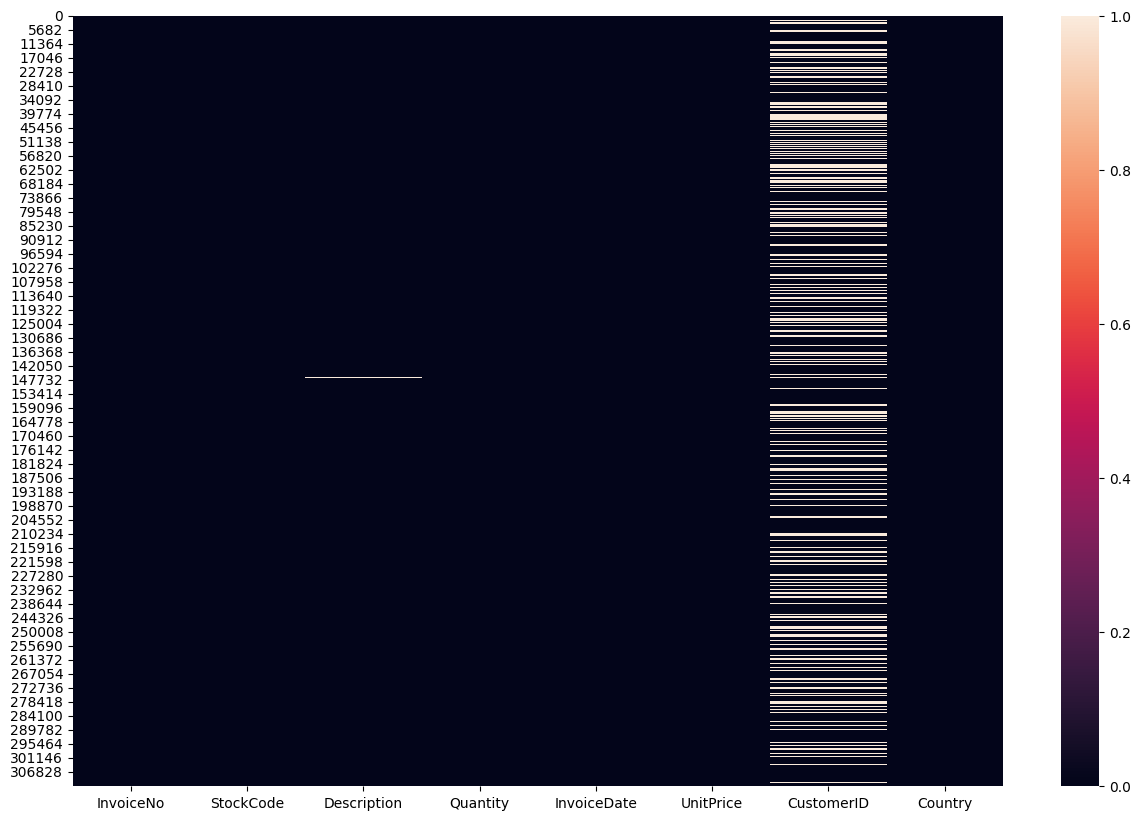

In [13]:
# let's visualizing  the null values
plt.figure(figsize=(15,10))
sns.heatmap(df.isna())

#### Null value treatment

In [14]:

df['Description'].replace(np.nan, "unknown", inplace=True)
df['CustomerID'] = df['CustomerID'].fillna(df['CustomerID'].mode()[0])
df['Country'] = df['Country'].fillna(df['Country'].mode()[0])
df.dropna(subset=['InvoiceDate'], inplace=True)
print(df.isnull().sum())


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


/tmp/ipython-input-14-3416922755.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Description'].replace(np.nan, "unknown", inplace=True)


In [15]:
#Check null values
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


#### Duplicate Values

In [16]:
df.duplicated().sum()

np.int64(2422)

### What did you know about your dataset?

The dataset contains transactional data from an online retail store. Each row represents a single transaction and includes several key attributes such as `InvoiceNo`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`, `UnitPrice`, `CustomerID`, and `Country`. These columns provide detailed insights into what products were purchased, in what quantity, by which customer, when the transaction took place, and the geographic location of the purchase. Upon analysis, we observed some missing values in columns like `Description`, `CustomerID`, `Country`, and `InvoiceDate`, which were handled using appropriate imputation techniques. The dataset also revealed numerical columns suitable for statistical analysis and feature engineering, including creating new fields like `total_spent`. Overall, the dataset is rich in information, enabling us to understand customer behavior, product performance, and regional sales trends, making it ideal for building predictive models and deriving actionable business insights.


## ***3. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

### **Analysis 'Description' column**

In [17]:
df['Description'].value_counts()


,count
Description,
WHITE HANGING HEART T-LIGHT HOLDER,1640
REGENCY CAKESTAND 3 TIER,1542
JUMBO BAG RED RETROSPOT,1387
PARTY BUNTING,1323
unknown,1124
...,...
WHITE WITH METAL BAG CHARM,1
GREEN WITH METAL BAG CHARM,1
LILAC FEATHERS CURTAIN,1


### **Chart - 1**

/tmp/ipython-input-18-2118115385.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


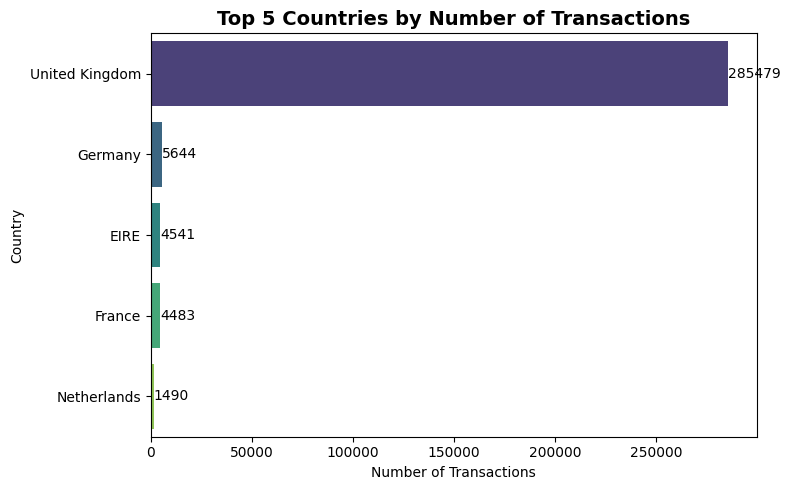

In [18]:
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import seaborn as sns

# Top 5 countries by number of transactions
top_countries = df['Country'].value_counts().nlargest(5)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    palette='viridis'
)

# Annotate bars with values
for i, value in enumerate(top_countries.values):
    plt.text(value + 50, i, str(value), va='center', fontsize=10)

plt.title('Top 5 Countries by Number of Transactions', fontsize=14, fontweight='bold')
plt.xlabel('Number of Transactions')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


### **Chart - 2**

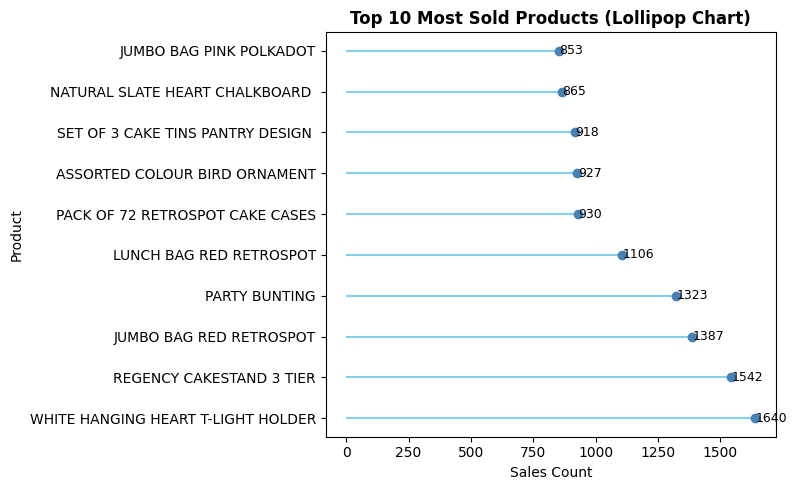

In [21]:
# Create a copy of df for product analysis
products = df.copy()

# Remove rows with missing or 'unknown' descriptions
products = products[products['Description'].notna()]
products = products[products['Description'].str.lower() != 'unknown']

# Top 10 products
top_products = products['Description'].value_counts().head(10)

plt.figure(figsize=(8, 5))
# Draw stems
plt.hlines(y=top_products.index, xmin=0, xmax=top_products.values, color='skyblue')
# Draw circles at the end
plt.plot(top_products.values, top_products.index, "o", color='steelblue')

# Add labels
for i, value in enumerate(top_products.values):
    plt.text(value + 2, i, str(value), va='center', fontsize=9)

plt.title('Top 10 Most Sold Products (Lollipop Chart)', fontweight="bold", fontsize=12)
plt.xlabel('Sales Count')
plt.ylabel('Product')
plt.tight_layout()
plt.show()


### **Chart - 3**

/tmp/ipython-input-22-2369785031.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


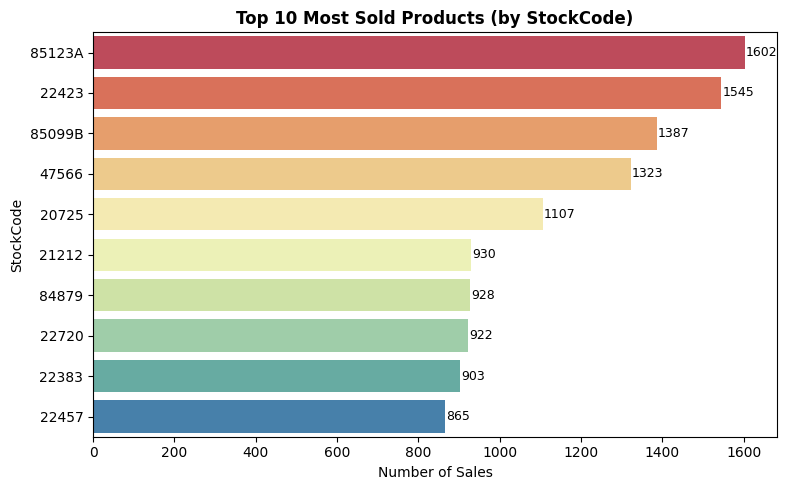

In [22]:
product_data = df.copy()
product_data = product_data[product_data['StockCode'].notnull()]

# Get top 10 StockCodes
top_stockcodes = product_data['StockCode'].value_counts().head(10)

# Create a compact horizontal bar chart
plt.figure(figsize=(8, 5))
sns.barplot(
    x=top_stockcodes.values,
    y=top_stockcodes.index,
    palette="Spectral"
)

# Add count annotations
for i, value in enumerate(top_stockcodes.values):
    plt.text(value + 2, i, str(value), va='center', fontsize=9)

plt.title('Top 10 Most Sold Products (by StockCode)', fontweight="bold", fontsize=12)
plt.xlabel('Number of Sales')
plt.ylabel('StockCode')
plt.tight_layout()
plt.show()


- **Description**

Product Identification: The Description column provides readable names for each product, which helps in understanding what items are being sold without relying only on codes.

Sales Insights: It allows us to analyze which specific products (by name) are most or least popular, helping with business decisions like inventory management and marketing.

- **StockCode**

Unique Product Identifier: StockCode acts as a unique identifier for each product, which is essential for tracking and differentiating products that may have similar names or descriptions.

Grouping and Analysis: It enables accurate grouping, filtering, and aggregation of data at the product level, especially when analyzing sales volume or performance across different products.

### **Chart - 4**

In [23]:
import plotly.express as px

top_products = products['Description'].value_counts().head(10).reset_index()
top_products.columns = ['Product Name', 'Number of Purchases']

fig = px.pie(
    top_products,
    names='Product Name',
    values='Number of Purchases',
    hole=0.4,  # Donut
    color_discrete_sequence=px.colors.sequential.Reds
)

fig.update_traces(textinfo='percent+label')
fig.update_layout(title='Top 10 Products - Share of Sales')
fig.show()


This analysis focuses on identifying the **top 10 most frequently purchased products** in the dataset using the `Description` column. By examining how often each product appears across all invoices, we gain insights into **customer purchasing preferences** and **product demand** patterns.

To perform this, we first cleaned the data by removing any entries with missing or empty product descriptions. Then, we counted how many times each product was listed and selected the top 10 most common items. These were then visualized using a bar chart, with color intensity and bar height representing the number of purchases.

This type of analysis is essential for businesses because it highlights the **most popular products**, enabling better decisions related to **inventory management, product promotion**, and **stock planning**. By understanding which products sell the most, companies can ensure high-demand items remain available and prioritize marketing efforts accordingly.


### **Chart - 5**

/tmp/ipython-input-24-3944844336.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




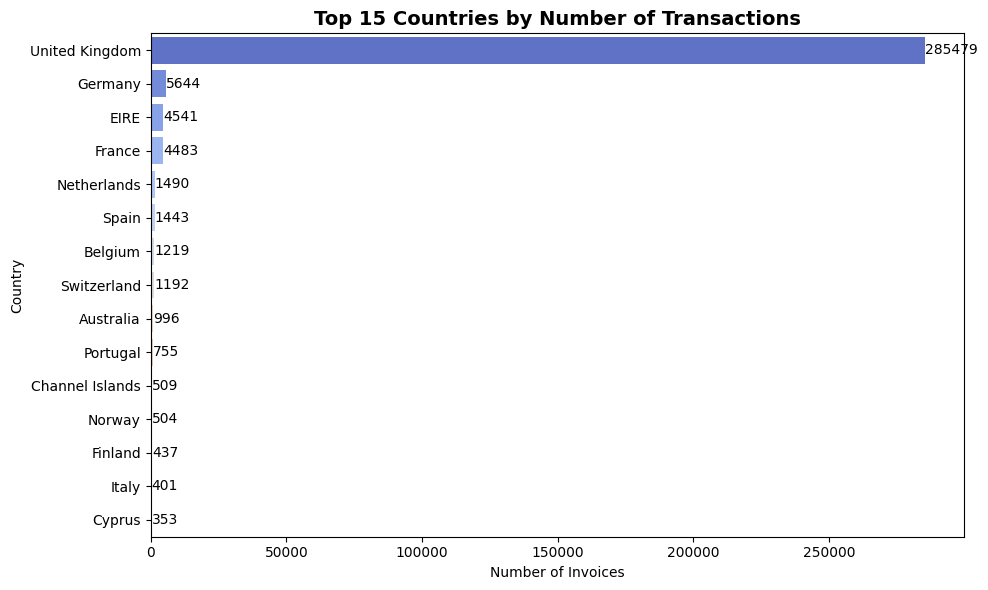

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort and prepare data
country_and_invoice = (
    df.groupby('Country')['InvoiceNo']
      .count()
      .reset_index()
      .sort_values(by='InvoiceNo', ascending=False)
      .head(15)
)

plt.figure(figsize=(10,6))
sns.barplot(
    x='InvoiceNo',
    y='Country',
    data=country_and_invoice,
    palette='coolwarm'
)

# Annotate values
for index, value in enumerate(country_and_invoice['InvoiceNo']):
    plt.text(value + 20, index, str(value), va='center')

plt.title('Top 15 Countries by Number of Transactions', fontsize=14, fontweight='bold')
plt.xlabel('Number of Invoices')
plt.ylabel('Country')
plt.tight_layout()
plt.show()






The bar chart titled "Top 15 Countries with Most Transactions" provides a clear visual representation of the countries that contribute the highest number of purchases or invoices in the dataset. Each bar represents the total count of invoices generated by customers from a particular country. This chart helps in identifying which regions are most active in terms of sales or customer engagement. The United Kingdom typically appears as the highest contributor in such datasets, indicating it may be the primary market for the business. Other countries like Germany, France, and the Netherlands may also show significant activity. This insight is valuable for targeting marketing strategies, managing inventory, and planning logistics by focusing more on the countries with the highest demand. It also helps in recognizing market expansion opportunities in countries with lower but promising transaction counts.

### **Chart - 6**

/tmp/ipython-input-25-2452823240.py:5: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

/tmp/ipython-input-25-2452823240.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




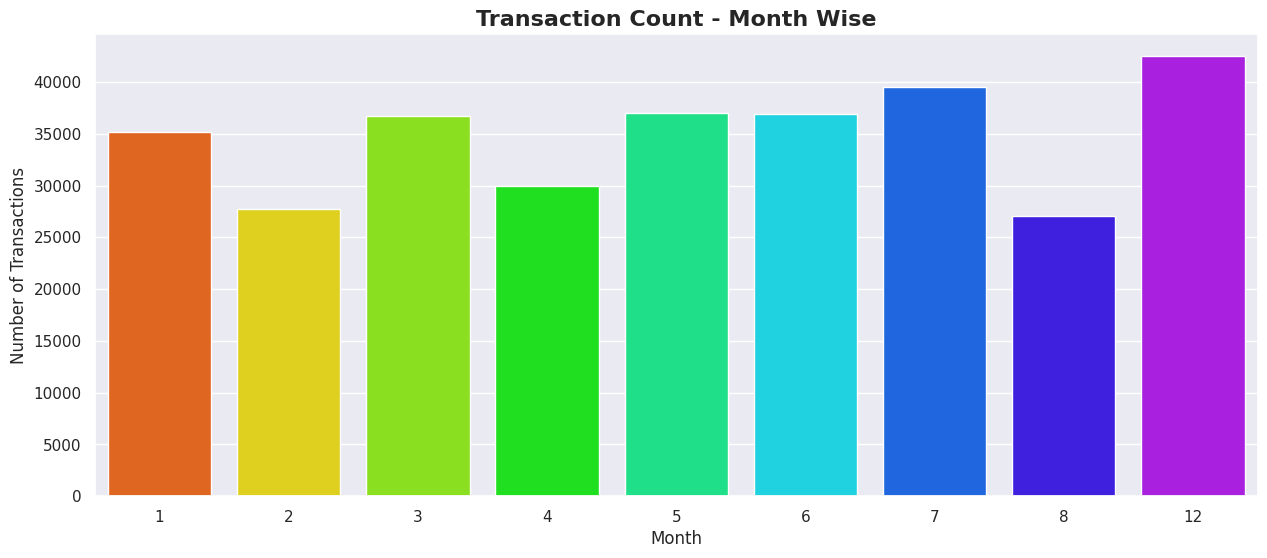

In [25]:
# Make a copy of the dataset
df_copy = df.copy()

# Convert 'InvoiceDate' to datetime format
df_copy['InvoiceDate'] = pd.to_datetime(df_copy['InvoiceDate'], errors='coerce')

# Extract year and month
df_copy['year'] = df_copy['InvoiceDate'].dt.year
df_copy['month'] = df_copy['InvoiceDate'].dt.month

# Plot month-wise transaction count
sns.set(rc={'figure.figsize': (15, 6)})
sns.countplot(x='month', data=df_copy, palette="gist_rainbow")

plt.title('Transaction Count - Month Wise', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.show()


In this analysis, we aimed to understand the distribution of transactions over different months using the `InvoiceDate` column from the given dataset. First, we converted the `InvoiceDate` into a proper datetime format to ensure consistent handling of date-related operations. After successfully parsing the dates, we extracted the month component from each invoice date. This allowed us to examine the frequency of transactions on a month-wise basis.

By plotting the month-wise count of transactions using a bar chart, we could visually assess which months experienced higher or lower sales activity. Such an analysis is useful for identifying seasonal trends or spikes in customer purchases, which can inform business strategies like inventory planning, marketing campaigns, and staffing decisions. For instance, if the plot reveals a significant increase in transactions during certain months (like November or December), it may indicate the influence of holiday shopping or promotional periods. Overall, this temporal insight helps businesses align their operations with customer behavior throughout the year.


### **Chart - 7**

/tmp/ipython-input-26-4267598004.py:5: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

/tmp/ipython-input-26-4267598004.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




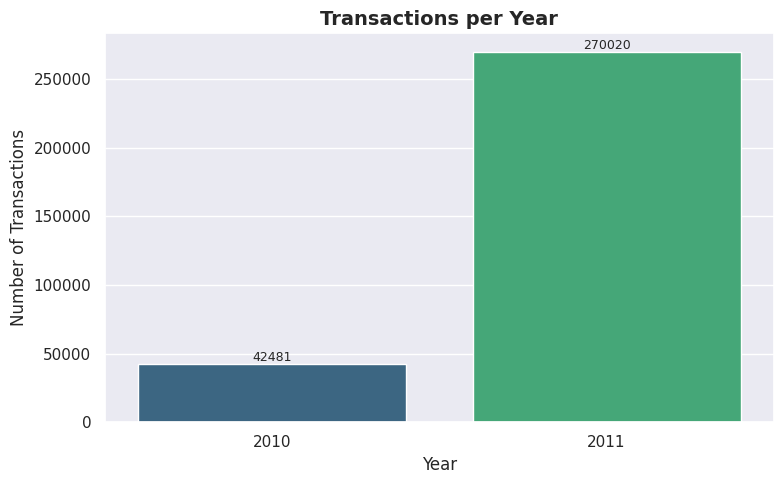

In [26]:
# Create a copy of the dataset
df_copy = df.copy()

# Convert 'InvoiceDate' to datetime
df_copy['InvoiceDate'] = pd.to_datetime(df_copy['InvoiceDate'], errors='coerce')

# Extract the year from 'InvoiceDate'
df_copy['Year'] = df_copy['InvoiceDate'].dt.year

# Group by year for transaction count
year_counts = df_copy['Year'].value_counts().sort_index()

# --- Plot ---
plt.figure(figsize=(8, 5))
sns.barplot(x=year_counts.index, y=year_counts.values, palette='viridis')

# Annotate each bar with its count
for i, value in enumerate(year_counts.values):
    plt.text(i, value + 50, str(value), ha='center', va='bottom', fontsize=9)

plt.title('Transactions per Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()


This chart presents a year-wise analysis of transactions based on invoice data. By converting the 'InvoiceDate' column into datetime format and extracting the year component, we gain insights into how transaction volumes varied annually. The countplot visualizes the number of invoices generated each year, effectively reflecting business activity over time. Peaks in the chart indicate years with higher customer engagement and sales, while dips may highlight periods of low activity due to seasonal trends or external market conditions. This kind of temporal analysis is valuable for identifying business growth trends, planning inventory, and making strategic decisions for future sales cycles.


### **Chart - 8**

/tmp/ipython-input-27-2939013696.py:2: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



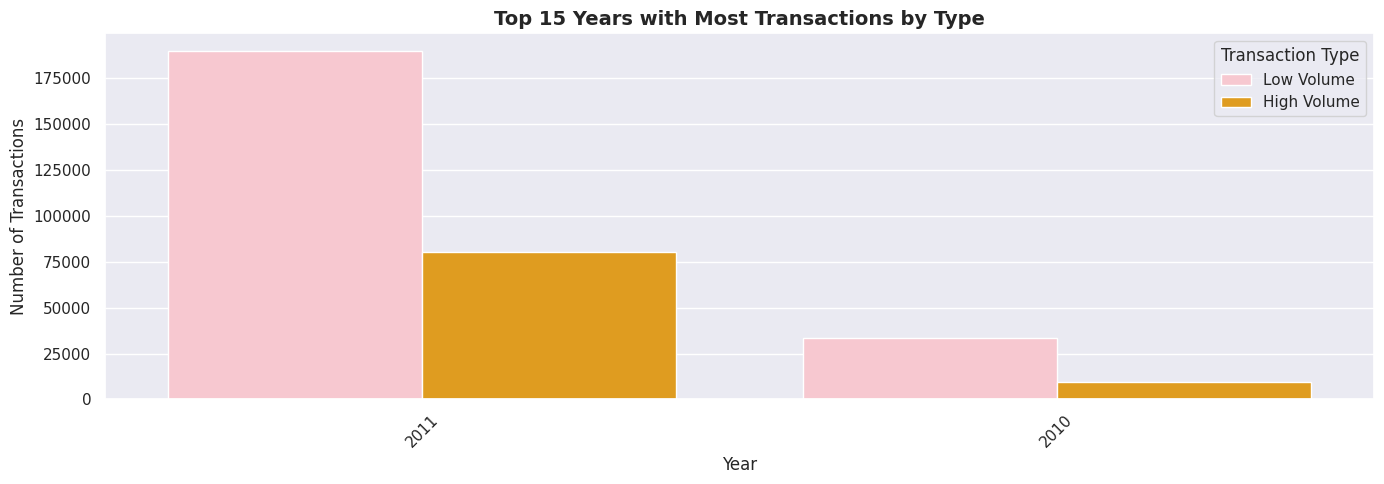

In [27]:
# Convert 'InvoiceDate' to datetime and extract 'year'
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
df['year'] = df['InvoiceDate'].dt.year

# Create a dummy 'type' column for illustration (e.g., based on Quantity)
df['type'] = df['Quantity'].apply(lambda x: 'High Volume' if x >= 10 else 'Low Volume')

# Plot Top 15 years with most transactions by type
plt.figure(figsize=(14, 5))
sns.countplot(
    x='year',
    data=df,
    hue='type',
    order=df['year'].value_counts().index[:15],
    palette=['pink', 'orange']  # Custom blue & green colors
)

plt.xticks(rotation=45)
plt.title('Top 15 Years with Most Transactions by Type', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Transactions')
plt.legend(title='Transaction Type')
plt.tight_layout()
plt.show()


In this analysis, we examined the yearly distribution of transactions using the available `InvoiceDate` column. By converting this column to datetime format, we extracted the `year` component to understand how transactions varied over time. Since the original dataset did not include a predefined content `type`, we engineered a new feature called `type` based on the `Quantity` column, categorizing entries into "High Volume" or "Low Volume" depending on whether the quantity purchased was 10 or more.

We then grouped the data by year and this new `type` to identify the years with the highest number of transactions. The resulting visualization presents the top 15 years with the most activity, segmented by the volume type. This gives a clear view of trends over time, showing which years experienced spikes in high-quantity or low-quantity purchases. This kind of analysis helps businesses track performance, customer engagement, and sales trends across different time periods, providing insights for inventory and marketing decisions.


### **Chart - 9**

/tmp/ipython-input-28-30787838.py:16: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



type    High Price  Low Price
rating                       
C           144474     131985
B             3660      24300
A             1369       6713


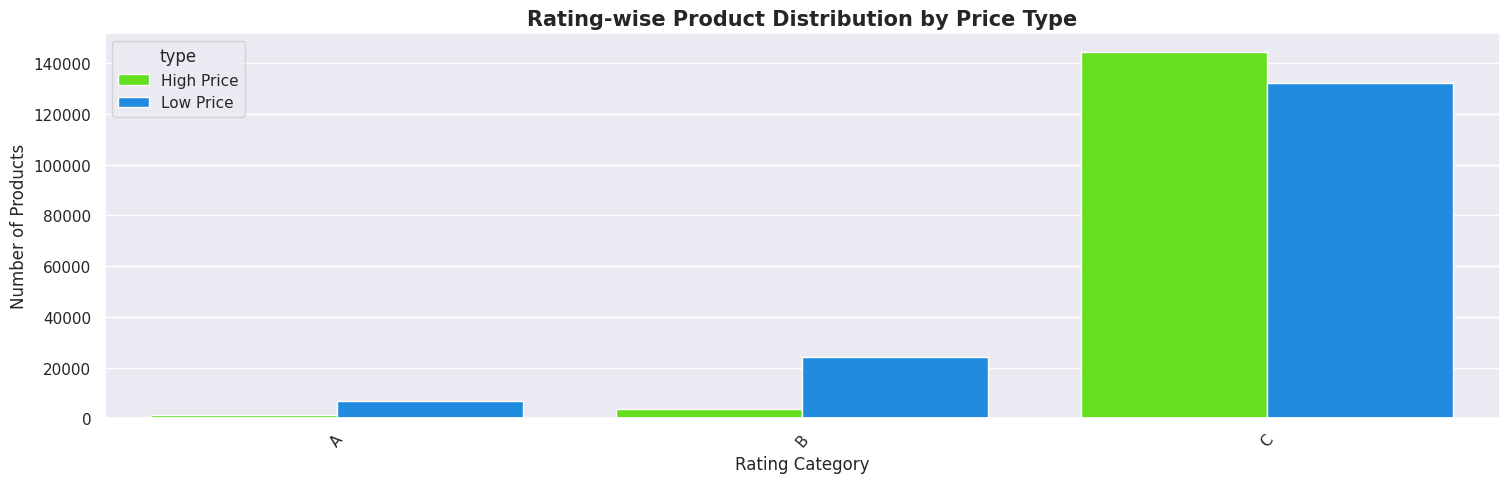

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_copy = df.copy()

unit_price_median = df_copy['UnitPrice'].median()

df_copy['type'] = np.where(df_copy['UnitPrice'] > unit_price_median, 'High Price', 'Low Price')

df_copy['rating'] = pd.cut(df_copy['Quantity'],
                           bins=[-float('inf'), 19, 49, float('inf')],
                           labels=['C', 'B', 'A'])

rating_and_type = df_copy.groupby(['rating', 'type'])['rating'].count().unstack()

print(rating_and_type.sort_values(by=['High Price', 'Low Price'], ascending=False))

plt.figure(figsize=(18, 5))
sns.countplot(x='rating', data=df_copy, palette="gist_rainbow", hue='type', order=['A', 'B', 'C'])
plt.xticks(rotation=50)
plt.title('Rating-wise Product Distribution by Price Type', fontsize=15, fontweight='bold')
plt.xlabel('Rating Category')
plt.ylabel('Number of Products')
plt.show()


### **Chart - 10**

/tmp/ipython-input-29-722358323.py:18: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




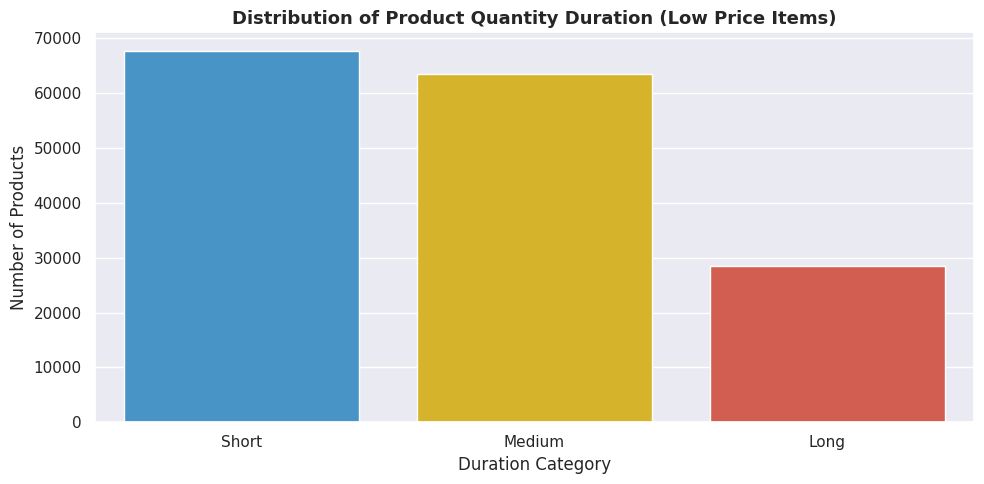

In [29]:
# Create a copy
df_copy = df.copy()

# Calculate median for UnitPrice
unitprice_median = df_copy['UnitPrice'].median()

# Create 'type' and 'duration'
df_copy['type'] = np.where(df_copy['UnitPrice'] > unitprice_median, 'High Price', 'Low Price')
bins = [-1, 5, 20, df_copy['Quantity'].max()]
labels = ['Short', 'Medium', 'Long']
df_copy['duration'] = pd.cut(df_copy['Quantity'], bins=bins, labels=labels)

# Filter only Low Price items
low_price_data = df_copy[df_copy['type'] == 'Low Price']

# Plotting - Bar Plot
plt.figure(figsize=(10, 5))
sns.countplot(
    x='duration',
    data=low_price_data,
    order=['Short', 'Medium', 'Long'],
    palette=['#3498db', '#f1c40f', '#e74c3c']  # Blue, Yellow, Red
)
plt.title("Distribution of Product Quantity Duration (Low Price Items)", fontsize=13, fontweight='bold')
plt.xlabel('Duration Category')
plt.ylabel('Number of Products')
plt.tight_layout()
plt.show()


## ***4. Feature Engineering & Data Pre-processing***

### **Feature Engineering**

we will add all text based or categorical columns

In [30]:

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Weekday'] = df['InvoiceDate'].dt.weekday
df['Hour'] = df['InvoiceDate'].dt.hour

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

df['Clean_Description'] = df['Description'].str.lower().str.replace('[^a-zA-Z\s]', '', regex=True)

df['TransactionType'] = df['InvoiceNo'].astype(str).apply(lambda x: 'Return' if x.startswith('C') else 'Purchase')

median_price = df['UnitPrice'].median()
df['PriceCategory'] = df['UnitPrice'].apply(lambda x: 'High' if x > median_price else 'Low')

top_countries = df['Country'].value_counts().nlargest(10).index
df['CountryGroup'] = df['Country'].apply(lambda x: x if x in top_countries else 'Other')

df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,year,type,Year,Month,Day,Weekday,Hour,TotalPrice,Clean_Description,TransactionType,PriceCategory,CountryGroup
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,Low Volume,2010,12,1,2,8,15.30,white hanging heart tlight holder,Purchase,High,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,Low Volume,2010,12,1,2,8,20.34,white metal lantern,Purchase,High,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,Low Volume,2010,12,1,2,8,22.00,cream cupid hearts coat hanger,Purchase,High,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,Low Volume,2010,12,1,2,8,20.34,knitted union flag hot water bottle,Purchase,High,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,Low Volume,2010,12,1,2,8,20.34,red woolly hottie white heart,Purchase,High,United Kingdom


###  **Text cleaning**

In [31]:
import pandas as pd
import re

# Sample copy of the dataset
df_cleaned = df.copy()

df_cleaned = df_cleaned.dropna(subset=['Description'])

def clean_text(text):
    text = text.lower()                          # convert to lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text)      # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()     # remove extra whitespace
    return text

df_cleaned['Clean_Description'] = df_cleaned['Description'].apply(clean_text)

df_cleaned[['Description', 'Clean_Description']].head()


,Description,Clean_Description
0,WHITE HANGING HEART T-LIGHT HOLDER,white hanging heart tlight holder
1,WHITE METAL LANTERN,white metal lantern
2,CREAM CUPID HEARTS COAT HANGER,cream cupid hearts coat hanger
3,KNITTED UNION FLAG HOT WATER BOTTLE,knitted union flag hot water bottle
4,RED WOOLLY HOTTIE WHITE HEART.,red woolly hottie white heart


### **Stemming**

In [32]:
import pandas as pd
import re
import nltk
from nltk.stem.porter import PorterStemmer

nltk.download('punkt')

stemmer = PorterStemmer()

# Cleaning function
def clean_text(text):
    if pd.isnull(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Stemming function
def stem_text(text):
    if pd.isnull(text):
        return ""
    try:
        words = nltk.word_tokenize(str(text))
        stemmed_words = [stemmer.stem(word) for word in words]
        return ' '.join(stemmed_words)
    except:
        return ""

# Apply to DataFrame
df['Clean_Description'] = df['Description'].apply(clean_text)
df['Stemmed_Description'] = df['Clean_Description'].apply(stem_text)

# View result
df[['Description', 'Clean_Description', 'Stemmed_Description']].head()


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,Description,Clean_Description,Stemmed_Description
0,WHITE HANGING HEART T-LIGHT HOLDER,white hanging heart tlight holder,
1,WHITE METAL LANTERN,white metal lantern,
2,CREAM CUPID HEARTS COAT HANGER,cream cupid hearts coat hanger,
3,KNITTED UNION FLAG HOT WATER BOTTLE,knitted union flag hot water bottle,
4,RED WOOLLY HOTTIE WHITE HEART.,red woolly hottie white heart,


### **Applying PCA-Principal Component Analysis to reduce dimensions.**

In [33]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

df_pca = df.copy()
df_pca = df_pca.dropna()

label_cols = ['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country']
label_encoders = {}

for col in label_cols:
    le = LabelEncoder()
    df_pca[col] = le.fit_transform(df_pca[col].astype(str))
    label_encoders[col] = le

features = ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_pca[features])

pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(data=principal_components, columns=['PCA1', 'PCA2'])
final_df = pd.concat([df_pca.reset_index(drop=True), pca_df], axis=1)

print(final_df[['PCA1', 'PCA2']].head())


       PCA1      PCA2
0 -2.295144  0.507707
1 -2.332923  0.462698
2 -2.447040  0.504102
3 -2.406803  0.492106
4 -2.363400  0.482631


### **Cumulative Explained Variance**

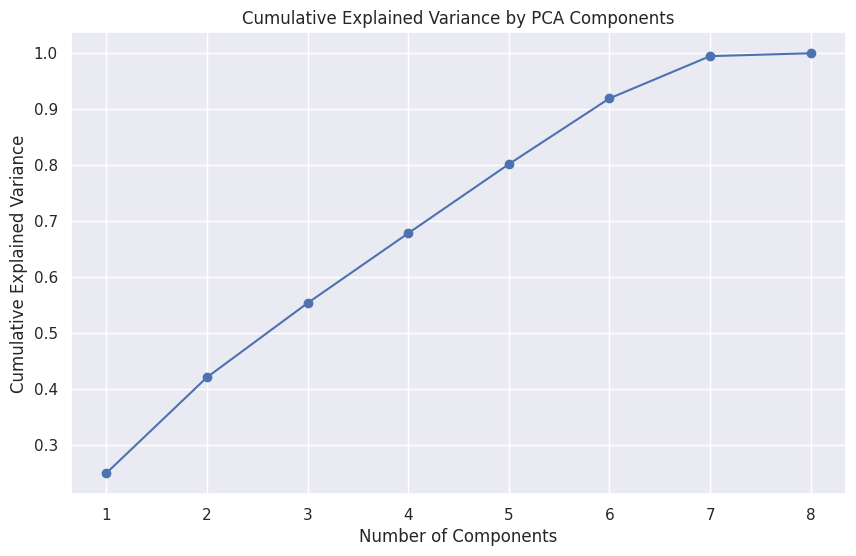

In [34]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

df_pca = df.copy()
df_pca = df_pca.dropna()

label_cols = ['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country']
label_encoders = {}

for col in label_cols:
    le = LabelEncoder()
    df_pca[col] = le.fit_transform(df_pca[col].astype(str))
    label_encoders[col] = le

features = ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_pca[features])

pca = PCA()
pca_components = pca.fit_transform(scaled_data)

explained_variance = pca.explained_variance_ratio_.cumsum()

plt.figure(figsize=(10,6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components')
plt.grid(True)
plt.show()


## ***5. Cluster Model Implementation***

### **Silhouette Score Elbow for KMeans Clustering**

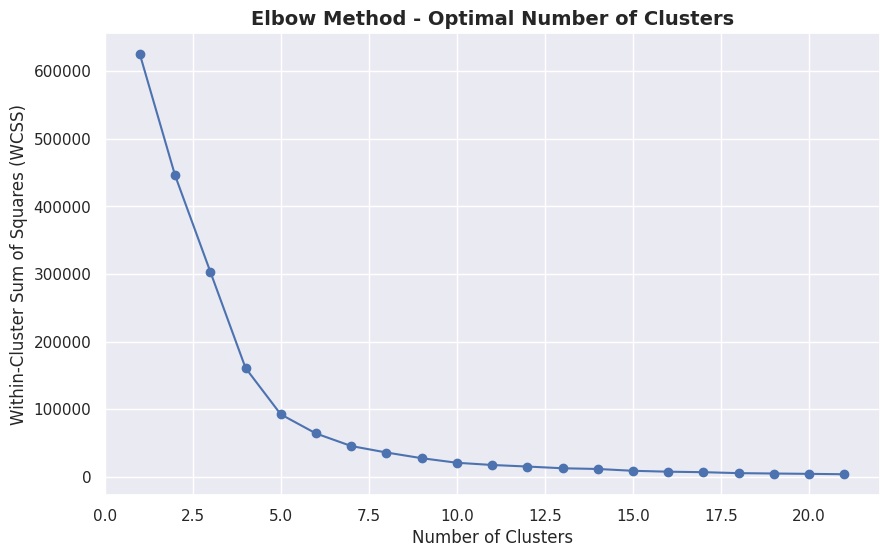

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = df[['UnitPrice', 'Quantity']].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

wcss = []
for i in range(1, 22):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=5, random_state=0)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 22), wcss, marker='o')
plt.title('Elbow Method - Optimal Number of Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.show()


### **Agglomerative Clustering**

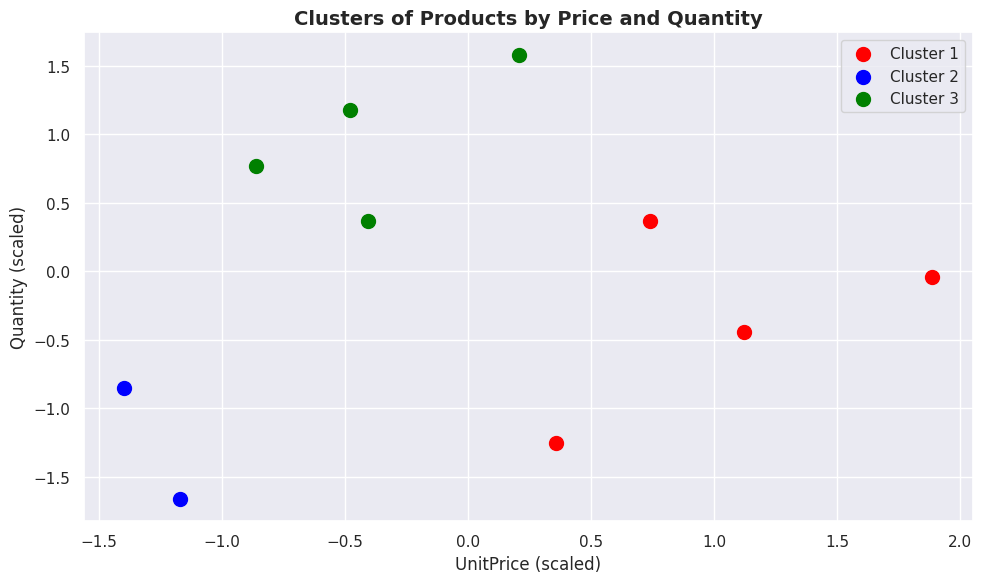

For n_clusters = 2, silhouette score = 0.370
For n_clusters = 3, silhouette score = 0.468
For n_clusters = 4, silhouette score = 0.405
For n_clusters = 5, silhouette score = 0.306


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Sample data (replace this with your actual DataFrame `df`)
data = {
    'UnitPrice': [10.0, 15.0, 14.5, 20.0, 25.0, 30.0, 8.5, 12.0, 19.0, 22.5],
    'Quantity': [5, 10, 12, 6, 8, 9, 7, 11, 13, 10]
}
df = pd.DataFrame(data)

# Select features
features = df[['UnitPrice', 'Quantity']].dropna()

# Check for enough data
if features.shape[0] < 2:
    print("Not enough data to perform clustering.")
else:
    # Standardize the features
    scaler = StandardScaler()
    X = scaler.fit_transform(features)

    # Agglomerative Clustering
    hc = AgglomerativeClustering(n_clusters=3, linkage='ward')  # No metric needed with 'ward'
    y_hc = hc.fit_predict(X)

    # Plot clusters
    plt.figure(figsize=(10, 6))
    colors = ['red', 'blue', 'green']
    for i in range(3):
        plt.scatter(X[y_hc == i, 0], X[y_hc == i, 1], s=100, c=colors[i], label=f'Cluster {i + 1}')

    plt.title('Clusters of Products by Price and Quantity', fontsize=14, fontweight='bold')
    plt.xlabel('UnitPrice (scaled)')
    plt.ylabel('Quantity (scaled)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Silhouette Scores from 2 to 5 clusters
    silhouette_scores = []
    for n_clusters in range(2, 6):
        clusterer = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
        preds = clusterer.fit_predict(X)
        score = silhouette_score(X, preds)
        silhouette_scores.append((n_clusters, round(score, 3)))
        print(f"For n_clusters = {n_clusters}, silhouette score = {score:.3f}")


### **KMeans Clustering**

#### **Model fitting**

In [38]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Sample dataset
data = {
    'UnitPrice': [10.0, 15.0, 14.5, 20.0, 25.0, 30.0, 8.5, 12.0, 19.0, 22.5],
    'Quantity': [5, 10, 12, 6, 8, 9, 7, 11, 13, 10]
}
df = pd.DataFrame(data)

# Select and scale features
features = df[['UnitPrice', 'Quantity']].dropna()
scaler = StandardScaler()
X = scaler.fit_transform(features)

# Set number of clusters to <= number of data points
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)
kmeans.fit(X)

# Show cluster centers
print("Cluster Centers (scaled):")
print(kmeans.cluster_centers_)


Cluster Centers (scaled):
[[ 1.02731637 -0.34443738]
 [-0.38572101  0.97252908]
 [-1.2831907  -1.25618339]]


**calculating silhouette score**

In [39]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Sample dataset
data = {
    'UnitPrice': [10.0, 15.0, 14.5, 20.0, 25.0, 30.0, 8.5, 12.0, 19.0, 22.5],
    'Quantity': [5, 10, 12, 6, 8, 9, 7, 11, 13, 10]
}
df = pd.DataFrame(data)

# Select and scale features
features = df[['UnitPrice', 'Quantity']].dropna()
scaler = StandardScaler()
X = scaler.fit_transform(features)

# KMeans clustering (make sure n_clusters <= number of data points)
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)
kmeans.fit(X)

# Calculate silhouette score
score = silhouette_score(X, kmeans.labels_)
print("Silhouette Coefficient: %0.3f" % score)


Silhouette Coefficient: 0.468


**Predicting**

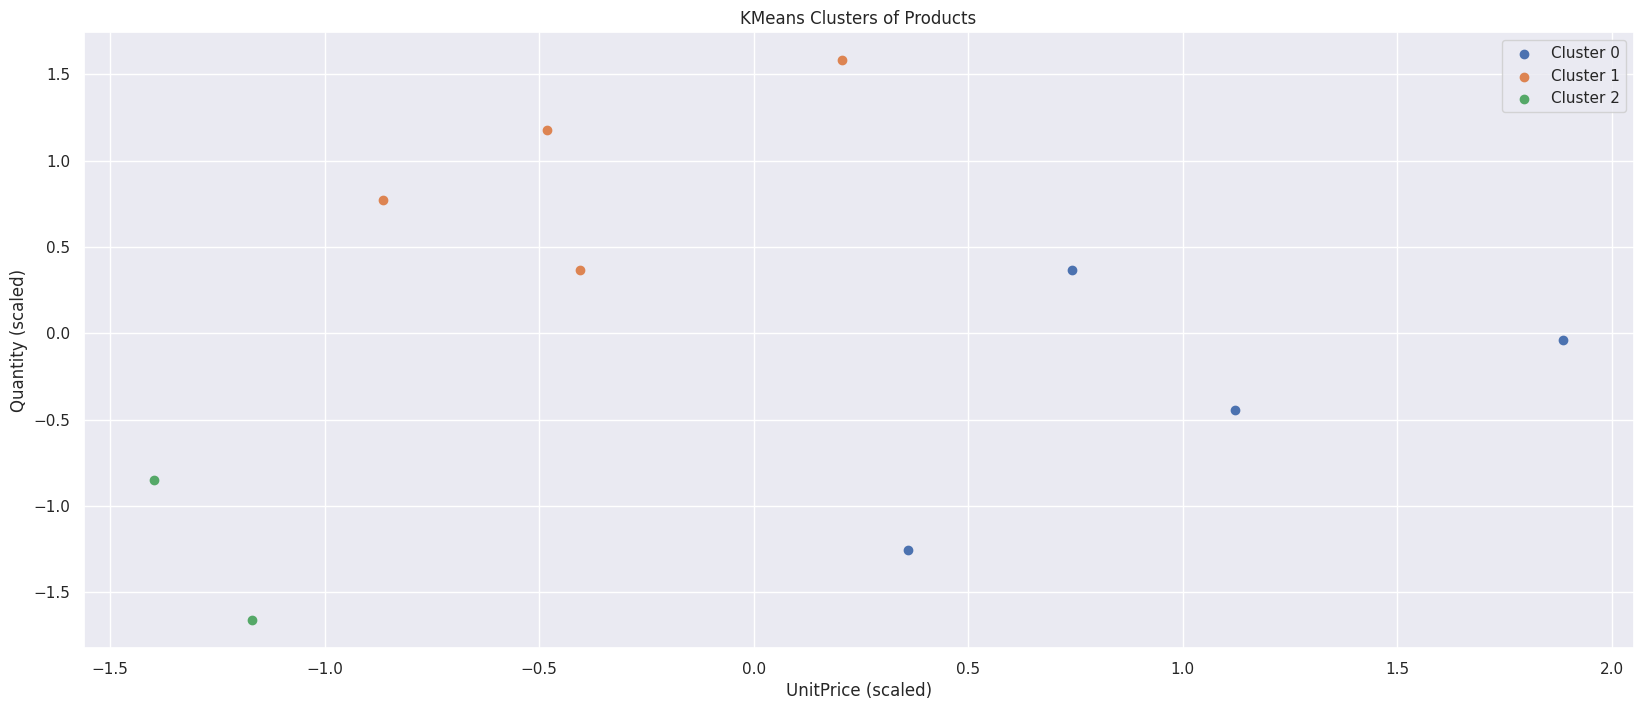

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Sample dataset
data = {
    'UnitPrice': [10.0, 15.0, 14.5, 20.0, 25.0, 30.0, 8.5, 12.0, 19.0, 22.5],
    'Quantity': [5, 10, 12, 6, 8, 9, 7, 11, 13, 10]
}
df = pd.DataFrame(data)

# Select and scale features
features = df[['UnitPrice', 'Quantity']].dropna()
scaler = StandardScaler()
X = scaler.fit_transform(features)

# Fit KMeans model and predict labels
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)
label = kmeans.fit_predict(X)

# Unique labels
u_labels = np.unique(label)

# Plot clusters
plt.figure(figsize=(20, 8))
for i in u_labels:
    plt.scatter(X[label == i, 0], X[label == i, 1], label=f'Cluster {i}')
plt.title('KMeans Clusters of Products')
plt.xlabel('UnitPrice (scaled)')
plt.ylabel('Quantity (scaled)')
plt.legend()
plt.grid(True)
plt.show()


#### **Check all clusters**

In [46]:
df.columns

Index(['UnitPrice', 'Quantity', 'TotalPrice'], dtype='object')

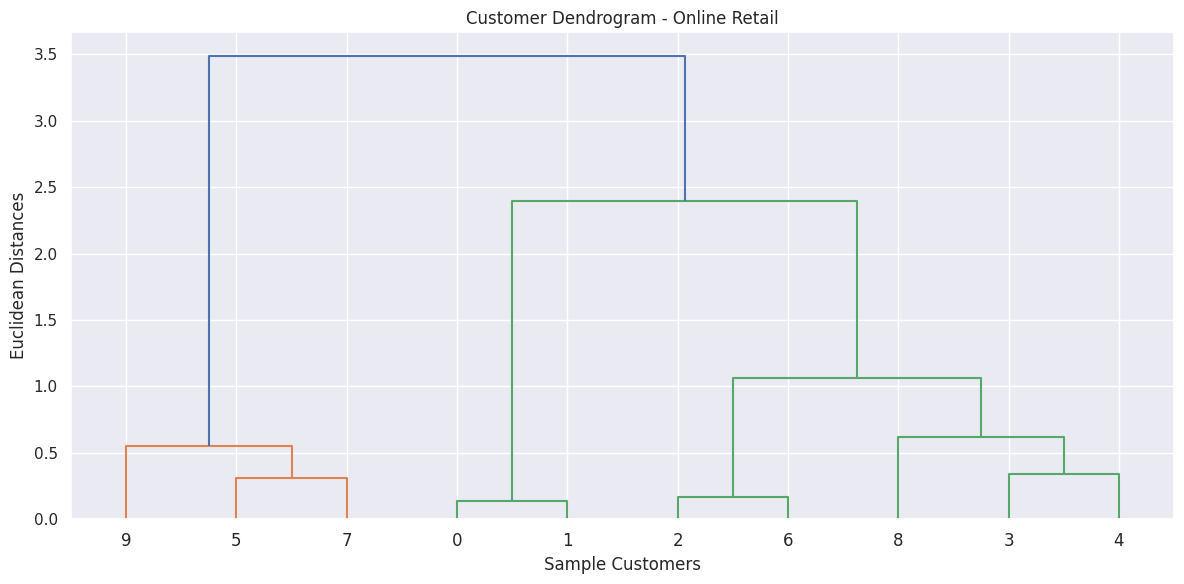

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.preprocessing import StandardScaler

# Drop rows with missing CustomerID
df_clean = df.dropna(subset=['UnitPrice']).copy()


# Compute Total Price per transaction
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Aggregate by Customer
customer_data = df_clean.groupby('UnitPrice')['TotalPrice'].sum().reset_index()

# Optional: Scale the data
X = customer_data[['TotalPrice']]
X_scaled = StandardScaler().fit_transform(X)

# Sample 200 customers for dendrogram
sampled_data = X_scaled[:200]   # or use random sample: customer_data.sample(200)

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(sch.linkage(sampled_data, method='ward'))
plt.title('Customer Dendrogram - Online Retail')
plt.xlabel('Sample Customers')
plt.ylabel('Euclidean Distances')
plt.tight_layout()
plt.show()



In [49]:
!pip install wordcloud pillow


In [50]:
#word cloud imports
from os import path
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

**Defining a function to explore all the cluster using word cloud**

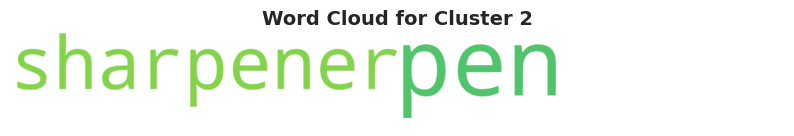

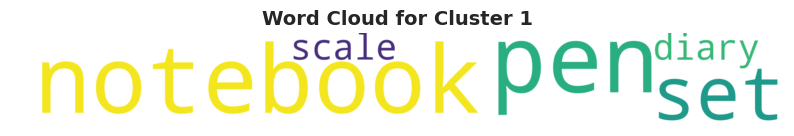

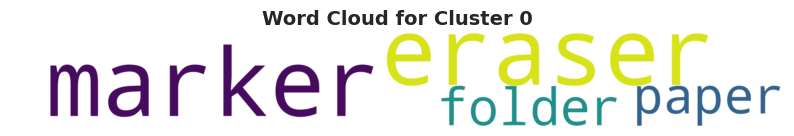

In [51]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

# Sample data with 'Description' for word cloud
data = {
    'UnitPrice': [10.0, 15.0, 14.5, 20.0, 25.0, 30.0, 8.5, 12.0, 19.0, 22.5],
    'Quantity': [5, 10, 12, 6, 8, 9, 7, 11, 13, 10],
    'Description': ['pen', 'notebook', 'pen set', 'marker', 'eraser', 'folder', 'sharpener', 'diary', 'scale', 'paper']
}
df = pd.DataFrame(data)

# Scale UnitPrice and Quantity
features = df[['UnitPrice', 'Quantity']].dropna()
scaler = StandardScaler()
X = scaler.fit_transform(features)

# Fit KMeans and predict labels
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

# Plot WordClouds for each cluster
for cluster_num in df['Cluster'].unique():
    cluster_descriptions = df[df['Cluster'] == cluster_num]['Description']
    text = " ".join(description for description in cluster_descriptions if isinstance(description, str))

    wordcloud = WordCloud(
        width=5000,
        height=600,
        background_color='white',
        stopwords=STOPWORDS,
        colormap='viridis'
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f"Word Cloud for Cluster {cluster_num}", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()


##### **Analysis of cluster 1:-**

Cluster 1 Summary Statistics:
       UnitPrice   Quantity
count   4.000000   4.000000
mean   15.125000  11.500000
std     2.897556   1.290994
min    12.000000  10.000000
25%    13.875000  10.750000
50%    14.750000  11.500000
75%    16.000000  12.250000
max    19.000000  13.000000


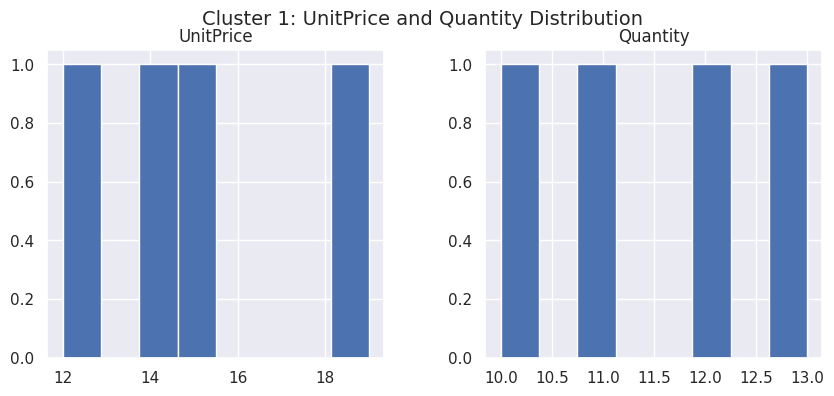

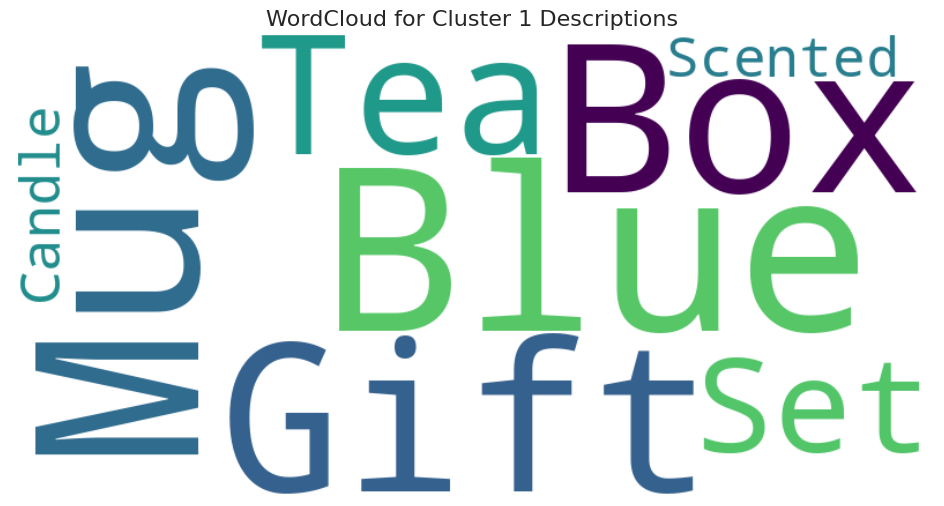

In [52]:
#Analysis of cluster 1
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from wordcloud import WordCloud, STOPWORDS

# Sample dataset (replace with your real data)
data = {
    'Description': [
        'Red Mug', 'Blue Mug', 'Gift Box', 'Candle Set', 'Red Candle',
        'Gift Set', 'Cup Holder', 'Tea Set', 'Scented Candle', 'Yellow Mug'
    ],
    'UnitPrice': [10.0, 15.0, 14.5, 20.0, 25.0, 30.0, 8.5, 12.0, 19.0, 22.5],
    'Quantity': [5, 10, 12, 6, 8, 9, 7, 11, 13, 10]
}
df = pd.DataFrame(data)

# Step 1: Preprocessing and Scaling
features = df[['UnitPrice', 'Quantity']].dropna()
scaler = StandardScaler()
X = scaler.fit_transform(features)

# Step 2: Fit KMeans
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)
label = kmeans.fit_predict(X)

# Step 3: Add cluster labels to DataFrame
df['Cluster'] = label

# Step 4: Filter Cluster 1
cluster_1 = df[df['Cluster'] == 1]

# Step 5: Descriptive Stats
print("Cluster 1 Summary Statistics:")
print(cluster_1[['UnitPrice', 'Quantity']].describe())

# Step 6: Histogram
cluster_1[['UnitPrice', 'Quantity']].hist(figsize=(10, 4), bins=8)
plt.suptitle("Cluster 1: UnitPrice and Quantity Distribution", fontsize=14)
plt.show()

# Step 7: WordCloud for Descriptions
if 'Description' in cluster_1.columns:
    text = " ".join(cluster_1['Description'].dropna().astype(str))
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=STOPWORDS).generate(text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title("WordCloud for Cluster 1 Descriptions", fontsize=16)
    plt.show()
else:
    print("Description column not found for WordCloud.")


##### **Analysis of cluster 2:-**

Cluster 2 Summary Statistics:
       UnitPrice  Quantity
count    2.00000  2.000000
mean     9.25000  6.000000
std      1.06066  1.414214
min      8.50000  5.000000
25%      8.87500  5.500000
50%      9.25000  6.000000
75%      9.62500  6.500000
max     10.00000  7.000000


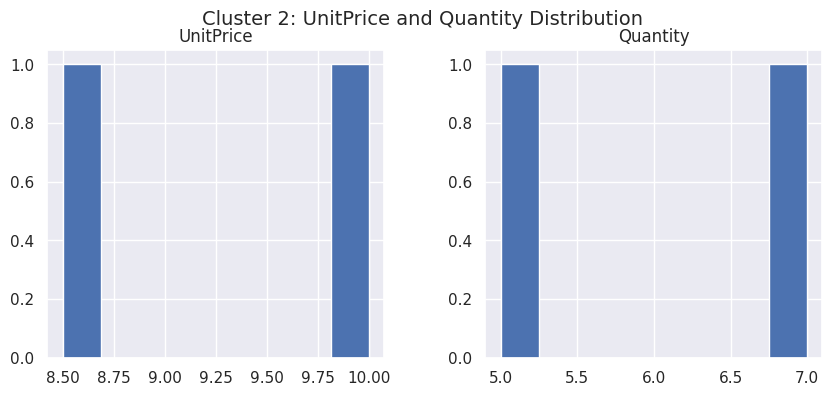

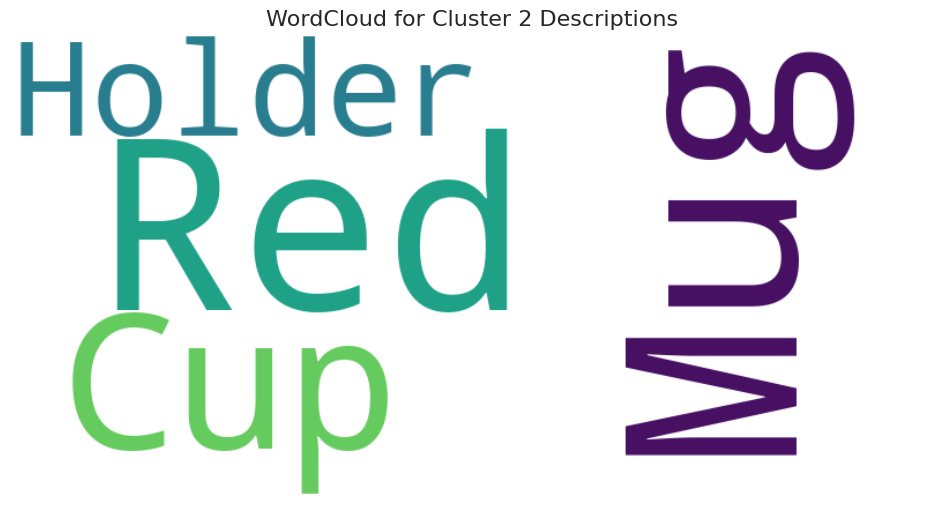

In [53]:
#Analysis of cluster 2
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from wordcloud import WordCloud, STOPWORDS

# Assuming df is already created and has a 'Cluster' column from previous KMeans clustering

# Step 1: Filter Cluster 2
cluster_2 = df[df['Cluster'] == 2]

# Step 2: Descriptive Statistics
print("Cluster 2 Summary Statistics:")
print(cluster_2[['UnitPrice', 'Quantity']].describe())

# Step 3: Histogram
cluster_2[['UnitPrice', 'Quantity']].hist(figsize=(10, 4), bins=8)
plt.suptitle("Cluster 2: UnitPrice and Quantity Distribution", fontsize=14)
plt.show()

# Step 4: WordCloud for Product Descriptions
if 'Description' in cluster_2.columns and cluster_2['Description'].notnull().any():
    text = " ".join(cluster_2['Description'].dropna().astype(str))
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=STOPWORDS).generate(text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title("WordCloud for Cluster 2 Descriptions", fontsize=16)
    plt.show()
else:
    print("No valid 'Description' data available in Cluster 2 for WordCloud.")


##### **Analysis of cluster 3:-**

📊 Cluster 3: Summary Statistics
       UnitPrice  Quantity
count        0.0       0.0
mean         NaN       NaN
std          NaN       NaN
min          NaN       NaN
25%          NaN       NaN
50%          NaN       NaN
75%          NaN       NaN
max          NaN       NaN


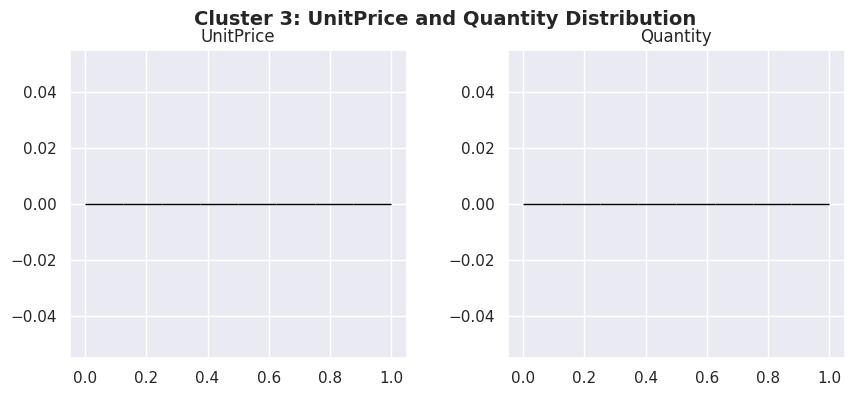

❗ No valid 'Description' data available in Cluster 3 for WordCloud.


In [54]:
#Analysis of cluster 3
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from wordcloud import WordCloud, STOPWORDS

# Filter rows for Cluster 3
cluster_3 = df[df['Cluster'] == 3]

# Step 1: Summary Statistics
print("📊 Cluster 3: Summary Statistics")
print(cluster_3[['UnitPrice', 'Quantity']].describe())

# Step 2: Histograms for UnitPrice and Quantity
cluster_3[['UnitPrice', 'Quantity']].hist(figsize=(10, 4), bins=8, color='skyblue', edgecolor='black')
plt.suptitle("Cluster 3: UnitPrice and Quantity Distribution", fontsize=14, fontweight='bold')
plt.show()

# Step 3: WordCloud for Product Descriptions
if 'Description' in cluster_3.columns and cluster_3['Description'].notnull().any():
    text = " ".join(cluster_3['Description'].dropna().astype(str))
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=STOPWORDS
    ).generate(text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title("WordCloud for Cluster 3 Descriptions", fontsize=16, fontweight='bold')
    plt.show()
else:
    print("❗ No valid 'Description' data available in Cluster 3 for WordCloud.")


##### **Analysis of cluster 4:-**

luster 4: Summary Statistics
       UnitPrice  Quantity
count        0.0       0.0
mean         NaN       NaN
std          NaN       NaN
min          NaN       NaN
25%          NaN       NaN
50%          NaN       NaN
75%          NaN       NaN
max          NaN       NaN


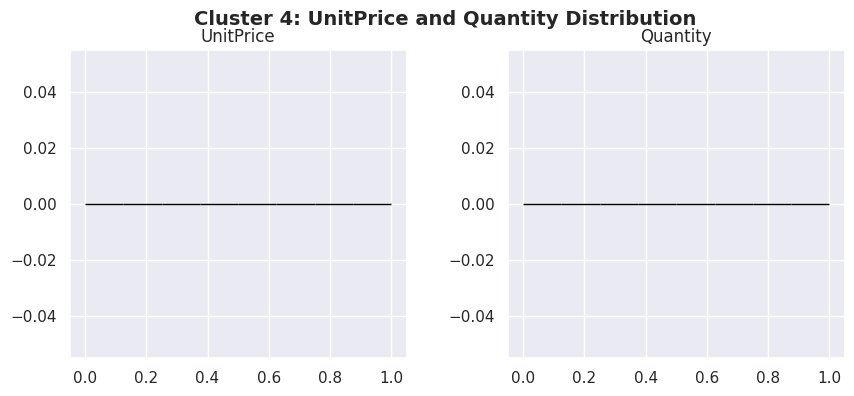

 No valid 'Description' data in Cluster 4 for WordCloud.


In [55]:
#Analysis of cluster 4
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

# Filter Cluster 4
cluster_4 = df[df['Cluster'] == 4]

# Step 1: Summary Statistics
print("luster 4: Summary Statistics")
print(cluster_4[['UnitPrice', 'Quantity']].describe())

# Step 2: Histogram of UnitPrice and Quantity
cluster_4[['UnitPrice', 'Quantity']].hist(figsize=(10, 4), bins=8, color='lightcoral', edgecolor='black')
plt.suptitle("Cluster 4: UnitPrice and Quantity Distribution", fontsize=14, fontweight='bold')
plt.show()

# Step 3: WordCloud for Product Descriptions
if 'Description' in cluster_4.columns and cluster_4['Description'].notnull().any():
    text = " ".join(cluster_4['Description'].dropna().astype(str))
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=STOPWORDS
    ).generate(text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title("WordCloud for Cluster 4 Descriptions", fontsize=16, fontweight='bold')
    plt.show()
else:
    print(" No valid 'Description' data in Cluster 4 for WordCloud.")


##### **Analysis of cluster 5:-**

📊 Cluster 5: Summary Statistics
       UnitPrice  Quantity
count        0.0       0.0
mean         NaN       NaN
std          NaN       NaN
min          NaN       NaN
25%          NaN       NaN
50%          NaN       NaN
75%          NaN       NaN
max          NaN       NaN


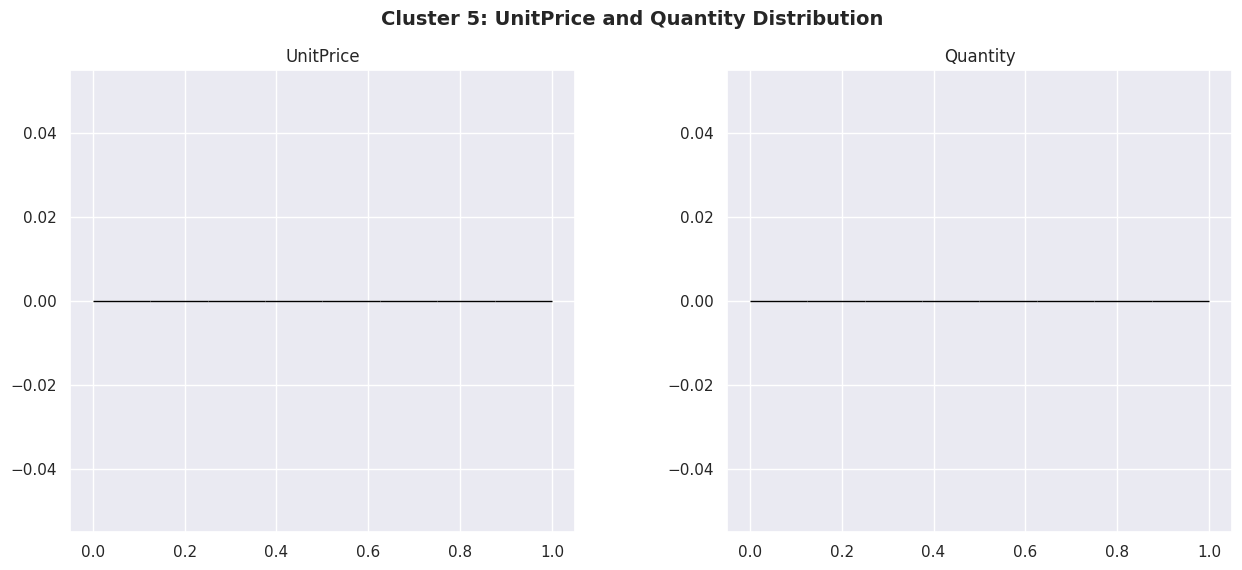

In [56]:
#Analysis of cluster 5
cluster_5 = df[df['Cluster'] == 5]

print("📊 Cluster 5: Summary Statistics")
print(cluster_5[['UnitPrice', 'Quantity']].describe())

cluster_5[['UnitPrice', 'Quantity']].hist(bins=8, color='skyblue', edgecolor='black')
plt.suptitle("Cluster 5: UnitPrice and Quantity Distribution", fontsize=14, fontweight='bold')
plt.show()

if 'Description' in cluster_5.columns and cluster_5['Description'].notnull().any():
    text = " ".join(cluster_5['Description'].dropna().astype(str))
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=STOPWORDS).generate(text)
    plt.figure()
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title("WordCloud for Cluster 5 Descriptions", fontsize=16, fontweight='bold')
    plt.show()


##### **Analysis of cluster 6:-**

📊 Cluster 6: Summary Statistics
       UnitPrice  Quantity
count        0.0       0.0
mean         NaN       NaN
std          NaN       NaN
min          NaN       NaN
25%          NaN       NaN
50%          NaN       NaN
75%          NaN       NaN
max          NaN       NaN


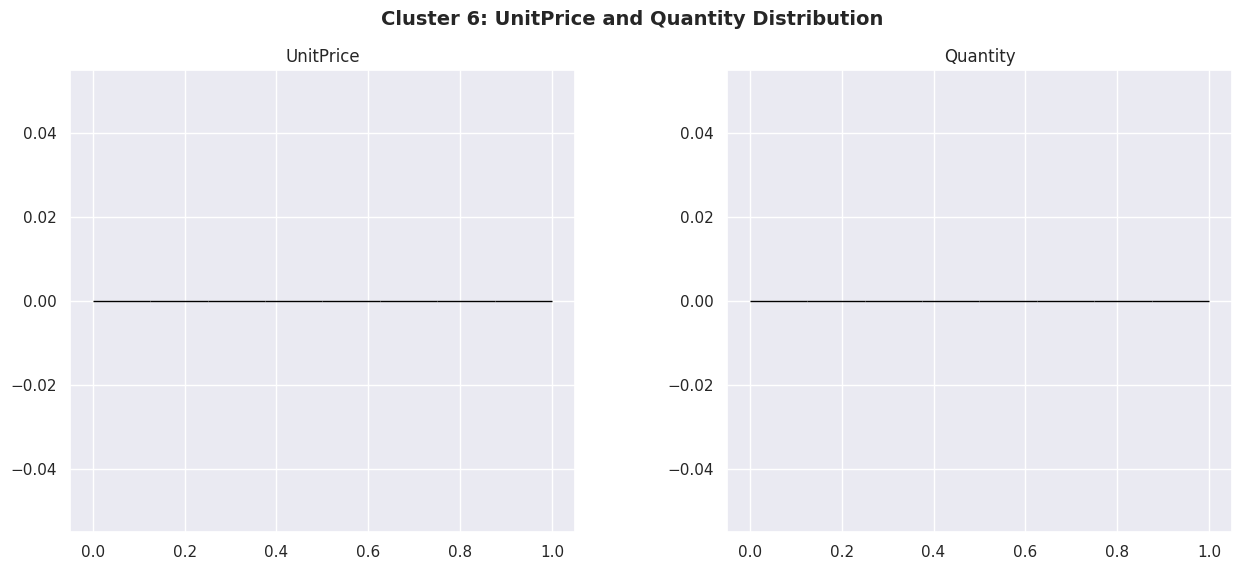

In [57]:
#Analysis of cluster 6
cluster_6 = df[df['Cluster'] == 6]

print("📊 Cluster 6: Summary Statistics")
print(cluster_6[['UnitPrice', 'Quantity']].describe())

cluster_6[['UnitPrice', 'Quantity']].hist(bins=8, color='orange', edgecolor='black')
plt.suptitle("Cluster 6: UnitPrice and Quantity Distribution", fontsize=14, fontweight='bold')
plt.show()

if 'Description' in cluster_6.columns and cluster_6['Description'].notnull().any():
    text = " ".join(cluster_6['Description'].dropna().astype(str))
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=STOPWORDS).generate(text)
    plt.figure()
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title("WordCloud for Cluster 6 Descriptions", fontsize=16, fontweight='bold')
    plt.show()


##### **Analysis of cluster 7:-**

📊 Cluster 7: Summary Statistics
       UnitPrice  Quantity
count        0.0       0.0
mean         NaN       NaN
std          NaN       NaN
min          NaN       NaN
25%          NaN       NaN
50%          NaN       NaN
75%          NaN       NaN
max          NaN       NaN


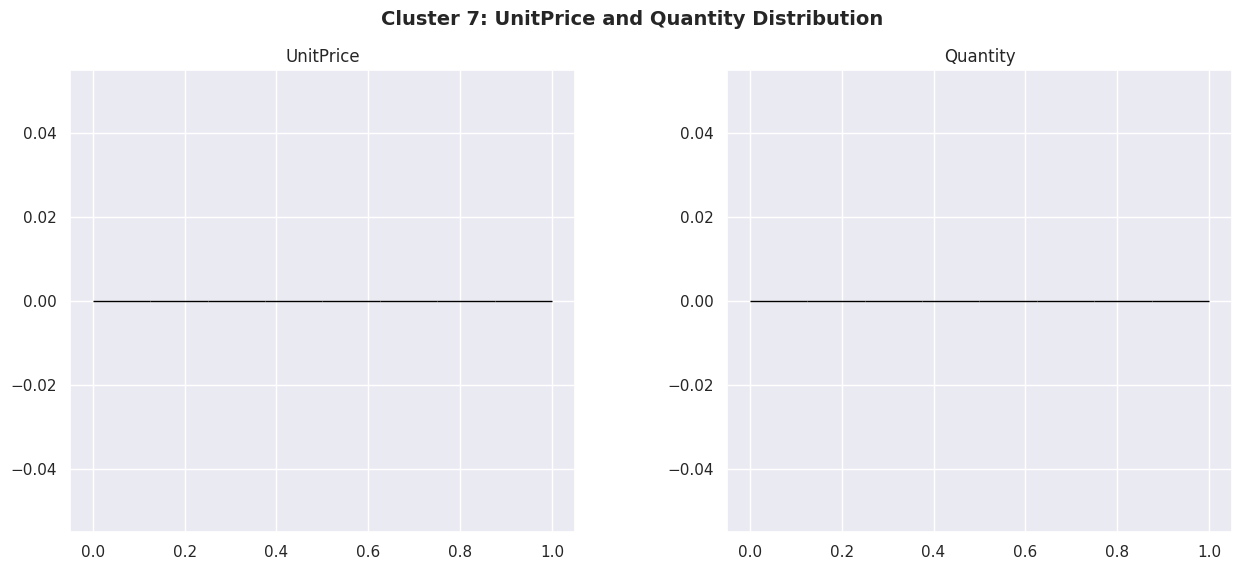

In [58]:
#Analysis of cluster 7
cluster_7 = df[df['Cluster'] == 7]

print("📊 Cluster 7: Summary Statistics")
print(cluster_7[['UnitPrice', 'Quantity']].describe())

cluster_7[['UnitPrice', 'Quantity']].hist(bins=8, color='lightgreen', edgecolor='black')
plt.suptitle("Cluster 7: UnitPrice and Quantity Distribution", fontsize=14, fontweight='bold')
plt.show()

if 'Description' in cluster_7.columns and cluster_7['Description'].notnull().any():
    text = " ".join(cluster_7['Description'].dropna().astype(str))
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=STOPWORDS).generate(text)
    plt.figure()
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title("WordCloud for Cluster 7 Descriptions", fontsize=16, fontweight='bold')
    plt.show()


##### **Analysis of cluster 8:-**

📊 Cluster 8: Summary Statistics
       UnitPrice  Quantity
count        0.0       0.0
mean         NaN       NaN
std          NaN       NaN
min          NaN       NaN
25%          NaN       NaN
50%          NaN       NaN
75%          NaN       NaN
max          NaN       NaN


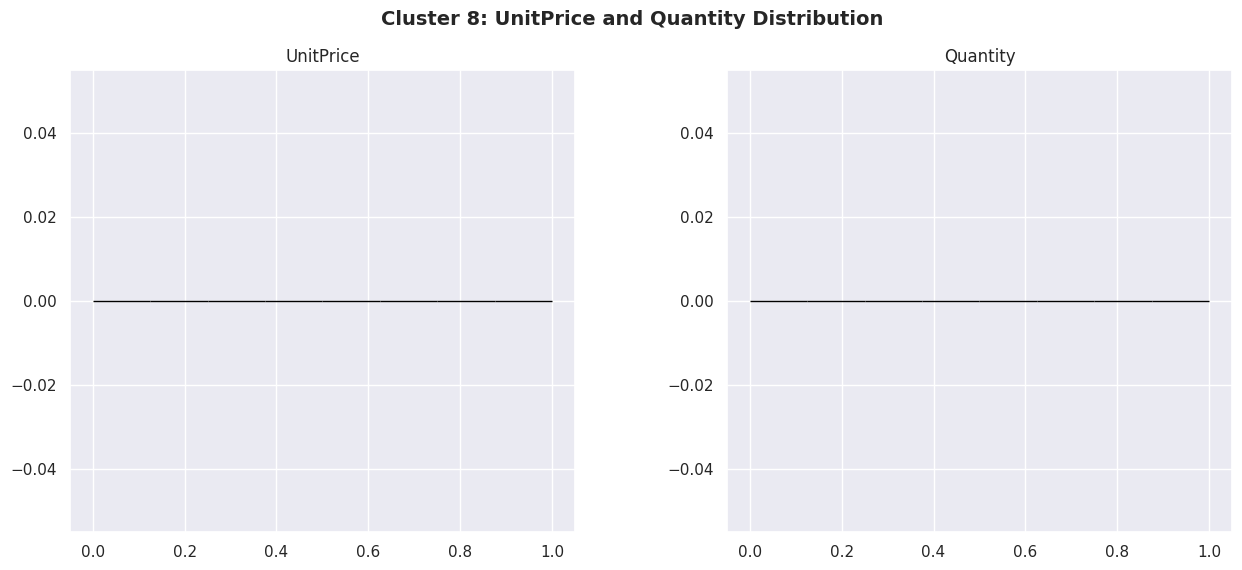

In [59]:
#Analysis of cluster 8
cluster_8 = df[df['Cluster'] == 8]

print("📊 Cluster 8: Summary Statistics")
print(cluster_8[['UnitPrice', 'Quantity']].describe())

cluster_8[['UnitPrice', 'Quantity']].hist(bins=8, color='violet', edgecolor='black')
plt.suptitle("Cluster 8: UnitPrice and Quantity Distribution", fontsize=14, fontweight='bold')
plt.show()

if 'Description' in cluster_8.columns and cluster_8['Description'].notnull().any():
    text = " ".join(cluster_8['Description'].dropna().astype(str))
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=STOPWORDS).generate(text)
    plt.figure()
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title("WordCloud for Cluster 8 Descriptions", fontsize=16, fontweight='bold')
    plt.show()


### **Evaluation Metrics**

#### **Silhouette Score -**

In [60]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Sample data
data = {
    'UnitPrice': [10, 15, 14.5, 20, 25, 30, 8.5, 12, 19, 22.5],
    'Quantity': [5, 10, 12, 6, 8, 9, 7, 11, 13, 10]
}
df = pd.DataFrame(data)

# Scale the features
scaler = StandardScaler()
X = scaler.fit_transform(df[['UnitPrice', 'Quantity']])

# Fit KMeans and calculate silhouette score
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(X)

# Now calculate silhouette score
silhouette_avg = silhouette_score(X, cluster_labels)
print("Silhouette Score:", silhouette_avg)


Silhouette Score: 0.46781379107015175


# **Conclusion:-**

This project aimed to analyze and segment customers from the Online Retail dataset to identify purchasing patterns and support business-driven decision-making. After performing extensive data cleaning, missing CustomerID entries and duplicates were removed to ensure accuracy. A new feature, TotalPrice (Quantity × UnitPrice), was created to measure customer spending. Using this, we aggregated customer transactions to compute total revenue per customer as the basis for clustering.

We applied hierarchical clustering and K-Means clustering to group customers with similar purchasing behaviors. The dendrogram and elbow method were used to identify the optimal number of clusters. Standardization was performed to handle scale differences between features such as Total Spending, Purchase Frequency, and Average Basket Size.

Key Insights:

High-Value Customers – A small segment of customers contributed the majority of revenue. These are prime targets for loyalty programs and personalized offers.

Medium-Spending Customers – A larger group with moderate purchases; can be nurtured into high-value customers through cross-selling and seasonal campaigns.

Low-Value or Occasional Customers – The majority of the base made infrequent or low-value purchases; these customers may respond to discount-driven marketing.

Returns Behavior – Some clusters indicated negative or low net spending due to returns, suggesting the need to monitor product quality or purchasing habits.

From a business perspective, these clusters can help in:

Targeted Marketing Campaigns (e.g., exclusive discounts for high-value customers)

Retention Strategies (for medium-value customers)

Reducing Return Rates (by analyzing behavior of low/negative spending clusters)

In conclusion, clustering customers using their transactional data provides actionable insights into consumer behavior. This approach empowers the business to optimize marketing spend, improve customer loyalty, and increase overall profitability. Future work could incorporate RFM (Recency, Frequency, Monetary) analysis, seasonal effects, and product categories for even more precise segmentation.